In [7]:
import pickle as pkl
from matplotlib import pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np
from glob import glob

In [8]:
decoding_data_prior = pkl.load(
    open(
        "../data/crossprediction/2864dca1-38d8-464c-9777-f6fdfd5e63b5_results_prior_choice.pkl",
        "rb",
    )
)

decoding_data_stimulus = pkl.load(
    open(
        "../data/crossprediction/2864dca1-38d8-464c-9777-f6fdfd5e63b5_results_stim_choice.pkl",
        "rb",
    )
)

In [9]:
def flatten_prediction_dict(animal_dict, source_type, animal_id="uno"):
    records = []
    for region_1, nested_dict in animal_dict.items():
        for region_2, frame_dict in nested_dict.items():
            for frame_pair, metrics in frame_dict.items():

                source_frame, choice_frame = frame_pair
                r2 = metrics.get("r2_scores")

                if isinstance(r2, (list, np.ndarray)):
                    for score in r2:
                        records.append(
                            {
                                "animal": animal_id,
                                "region_1": region_1,
                                "region_2": region_2,
                                "source_type": source_type,  # "Prior" or "Stimulus"
                                "source_frame": source_frame,  # Prior=0; Stimulus=0,1,2
                                "choice_frame": choice_frame,  # 0, 1, or 2
                                "r2_score": score,
                            }
                        )
                else:
                    records.append(
                        {
                            "animal": animal_id,
                            "region_1": region_1,
                            "region_2": region_2,
                            "source_type": source_type,
                            "source_frame": source_frame,
                            "choice_frame": choice_frame,
                            "r2_score": r2,
                        }
                    )
    return pd.DataFrame(records)

In [10]:
df_prior = flatten_prediction_dict(animal_dict=decoding_data_prior, source_type="prior")

In [11]:
df_stimulus = flatten_prediction_dict(animal_dict=decoding_data_stimulus, source_type="stim")

In [12]:
df_raw = pd.concat([df_prior, df_stimulus], ignore_index=True)

In [18]:
# drop a bunch
# df_raw = df_raw[(~df_raw["choice_frame"].isin([0, 1])) & (df_raw["source_frame"] == 0)]
df_raw = df_raw[(~df_raw["choice_frame"].isin([0, 1])) & ((df_raw["source_frame"] == 0))]

In [19]:
df_raw

,animal,region_1,region_2,source_type,source_frame,choice_frame,r2_score
10,uno,AUDp,AUDp,prior,0,2,0.447317
11,uno,AUDp,AUDp,prior,0,2,0.421679
12,uno,AUDp,AUDp,prior,0,2,0.342964
13,uno,AUDp,AUDp,prior,0,2,0.496086
14,uno,AUDp,AUDp,prior,0,2,0.338233
...,...,...,...,...,...,...,...
31705,uno,VISrl,VISrl,stim,0,2,0.652109
31706,uno,VISrl,VISrl,stim,0,2,0.563683
31707,uno,VISrl,VISrl,stim,0,2,0.529035
31708,uno,VISrl,VISrl,stim,0,2,0.682187


In [20]:
# df_mean_frames = (
#     df_raw.groupby(["source_type", "region_1", "region_2", "source_frame", "choice_frame"])[
#         "r2_score"
#     ]
#     .mean()
#     .reset_index()
# )

# df_best_predictor = (
#     df_mean_frames.groupby(["source_type", "region_1", "region_2", "choice_frame"])["r2_score"]
#     .max()
#     .reset_index()
# )
# compare_df = df_best_predictor.pivot(
#     index=["region_1", "region_2", "choice_frame"], columns="source_type", values="r2_score"
# ).reset_index()

In [21]:
idx = df_raw.groupby("region_2")["r2_score"].idxmax()
df_winners = df_raw.loc[idx].sort_values("r2_score", ascending=False).reset_index(drop=True)
print(df_winners[["region_2", "region_1", "source_type", "r2_score"]].head(10))

  region_2 region_1 source_type  r2_score
0   VISpor     VISp        stim  0.694846
1     VISl     VISp        stim  0.691046
2    VISal     VISp        stim  0.685700
3    VISrl     VISp        stim  0.682644
4    SSp-n    SSp-n        stim  0.626684
5    SSp-m    SSp-m        stim  0.623387
6   SSp-un   SSp-un       prior  0.620470
7  SSp-bfd  SSp-bfd        stim  0.616198
8      TEa     VISp        stim  0.605864
9     VISp     VISp        stim  0.588400


In [22]:
import seaborn as sns

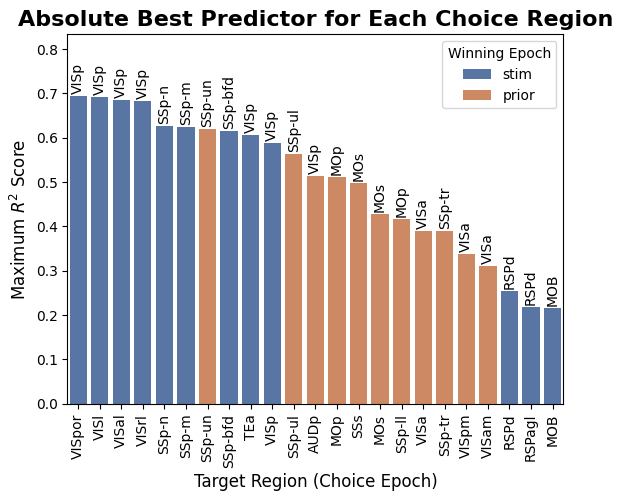

In [23]:
ax = sns.barplot(
    data=df_winners,
    x="region_2",
    y="r2_score",
    hue="source_type",
    dodge=False,  # Keeps bars centered on the x-ticks
    palette=["#4C72B0", "#DD8452"],  # Distinct colors for Prior/Stimulus
)

# 2. Annotate the winning Source Region ('region_1') on top of every bar
for index, row in df_winners.iterrows():
    # Place the text slightly above the top of the bar
    plt.text(
        x=index,
        y=row["r2_score"] + 0.005,  # Adjust the 0.005 if the text is too high/low
        s=row["region_1"],  # The name of the winning source region
        color="black",
        ha="center",
        va="bottom",
        rotation=90,  # Rotate text so it doesn't overlap
        fontsize=10,
    )


plt.title("Absolute Best Predictor for Each Choice Region", fontsize=16, fontweight="bold")
plt.xlabel("Target Region (Choice Epoch)", fontsize=12)
plt.ylabel("Maximum $R^2$ Score", fontsize=12)
plt.ylim(0, df_winners["r2_score"].max() * 1.2)
plt.xticks(rotation=90)
plt.legend(title="Winning Epoch", loc="upper right")

In [2]:
files_stim = glob("../data/crossprediction/*stim*.pkl")
files_prior = glob("../data/crossprediction/*prior*.pkl")

In [6]:
for idx, (filea, fileb) in enumerate(zip(files_stim, files_prior)):
    eid_a = filea.split("/")[-1].split("_")[0]
    eid_b = fileb.split("/")[-1].split("_")[0]
    assert eid_a == eid_b